# EDA: Car Damage Detection

Ноутбук для первичного считывания датасета `CarDD_COCO` в формате COCO.

In [9]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

## Пути к данным

In [10]:
def find_project_root(start=None) -> Path:
    """Find project root by walking up until data/raw/CarDD_COCO exists."""
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "data" / "raw" / "CarDD_COCO").exists():
            return path
    raise FileNotFoundError("Could not find data/raw/CarDD_COCO from current working directory")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "CarDD_COCO"
ANNOTATIONS_DIR = DATA_DIR / "annotations"

SPLITS = {
    "train": {
        "images_dir": DATA_DIR / "train2017",
        "annotations_path": ANNOTATIONS_DIR / "instances_train2017.json",
    },
    "val": {
        "images_dir": DATA_DIR / "val2017",
        "annotations_path": ANNOTATIONS_DIR / "instances_val2017.json",
    },
    "test": {
        "images_dir": DATA_DIR / "test2017",
        "annotations_path": ANNOTATIONS_DIR / "instances_test2017.json",
    },
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")

for split, paths in SPLITS.items():
    print(
        f"{split:>5}: images_dir={paths['images_dir'].exists()}, "
        f"annotations={paths['annotations_path'].exists()}"
    )

Project root: /Users/ektar/Desktop/Python Projects/car-damage-e2e
Data dir:     /Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO
train: images_dir=True, annotations=True
  val: images_dir=True, annotations=True
 test: images_dir=True, annotations=True


## Считывание COCO-аннотаций

In [11]:
def read_coco_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def coco_to_dataframes(split: str, images_dir: Path, annotations_path: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    coco = read_coco_json(annotations_path)

    images_df = pd.DataFrame(coco.get("images", []))
    annotations_df = pd.DataFrame(coco.get("annotations", []))
    categories_df = pd.DataFrame(coco.get("categories", []))

    if not images_df.empty:
        images_df = images_df.copy()
        images_df["split"] = split
        images_df["image_path"] = images_df["file_name"].apply(lambda name: images_dir / name)
        images_df["image_exists"] = images_df["image_path"].apply(lambda path: path.exists())

    if not annotations_df.empty:
        annotations_df = annotations_df.copy()
        annotations_df["split"] = split

        if "bbox" in annotations_df.columns:
            bbox = pd.DataFrame(
                annotations_df["bbox"].tolist(),
                columns=["bbox_x", "bbox_y", "bbox_width", "bbox_height"],
                index=annotations_df.index,
            )
            annotations_df = pd.concat([annotations_df, bbox], axis=1)

    if not categories_df.empty:
        categories_df = categories_df.copy()
        categories_df["split"] = split

    return images_df, annotations_df, categories_df


split_frames = {}

for split, paths in SPLITS.items():
    split_frames[split] = coco_to_dataframes(
        split=split,
        images_dir=paths["images_dir"],
        annotations_path=paths["annotations_path"],
    )

images_df = pd.concat([frames[0] for frames in split_frames.values()], ignore_index=True)
annotations_df = pd.concat([frames[1] for frames in split_frames.values()], ignore_index=True)
categories_df = (
    pd.concat([frames[2] for frames in split_frames.values()], ignore_index=True)
    .drop(columns="split")
    .drop_duplicates()
    .sort_values("id")
    .reset_index(drop=True)
)

category_id_to_name = categories_df.set_index("id")["name"].to_dict()
annotations_df["category_name"] = annotations_df["category_id"].map(category_id_to_name)

print(f"Images:      {len(images_df):,}")
print(f"Annotations: {len(annotations_df):,}")
print(f"Categories:  {len(categories_df):,}")

Images:      4,000
Annotations: 8,740
Categories:  6


## Быстрая проверка считанных таблиц

In [12]:
summary_df = pd.DataFrame(
    {
        "images": images_df.groupby("split").size(),
        "annotations": annotations_df.groupby("split").size(),
        "missing_images": images_df.groupby("split")["image_exists"].apply(lambda s: (~s).sum()),
    }
).fillna(0).astype(int)

summary_df

,images,annotations,missing_images
split,,,
test,374,785,0
train,2816,6211,0
val,810,1744,0


In [13]:
categories_df

,id,name
0,1,dent
1,2,scratch
2,3,crack
3,4,glass shatter
4,5,lamp broken
5,6,tire flat


In [14]:
images_df.head()

,id,width,height,file_name,license,split,image_path,image_exists
0,1,1000,750,000001.jpg,0,train,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/train2017/000001.jpg,True
1,2,1000,667,000002.jpg,0,train,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/train2017/000002.jpg,True
2,3,1000,667,000003.jpg,0,train,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/train2017/000003.jpg,True
3,4,1000,667,000004.jpg,0,train,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/train2017/000004.jpg,True
4,5,1000,667,000005.jpg,0,train,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/train2017/000005.jpg,True


In [15]:
annotations_df.head()

,id,image_id,category_id,segmentation,area,bbox,iscrowd,attributes,split,bbox_x,bbox_y,bbox_width,bbox_height,category_name
0,1,1,2,"[[233.35, 46.65, 217.25, 58.24, 210.82, 65.97, 204.38, 78.2, 197.3, 93.0, 192.15, 104.59, 187.0, 112.96, 180.56, 123...",13584.0,"[167.04, 40.21, 202.79, 131.34]",0,{'occluded': False},train,167.04,40.21,202.79,131.34,scratch
1,2,1,6,"[[348.93, 137.7, 336.68, 141.53, 323.67, 146.12, 312.19, 151.48, 299.95, 158.37, 289.23, 164.49, 279.29, 171.38, 270...",298742.0,"[160.66, 112.45, 684.19, 551.02]",0,{'occluded': False},train,160.66,112.45,684.19,551.02,tire flat
2,3,2,6,"[[625.2, 252.5, 614.49, 257.86, 602.24, 265.51, 590.0, 273.93, 576.99, 280.05, 566.28, 287.7, 557.09, 296.12, 544.85...",114126.0,"[476.73, 241.02, 397.2, 346.68]",0,{'occluded': False},train,476.73,241.02,397.20,346.68,tire flat
3,4,3,6,"[[410.15, 0.71, 405.56, 11.43, 403.27, 22.91, 400.2, 35.92, 396.38, 47.4, 393.32, 58.88, 391.02, 70.36, 388.72, 82.6...",299792.0,"[354.29, 0.0, 645.71, 521.12]",0,{'occluded': False},train,354.29,0.00,645.71,521.12,tire flat
4,5,4,6,"[[325.2, 25.2, 314.49, 32.09, 305.31, 39.74, 292.3, 48.16, 281.58, 54.29, 271.63, 61.94, 261.68, 71.12, 252.5, 79.54...",383763.0,"[129.29, 0.0, 718.62, 649.69]",0,{'occluded': False},train,129.29,0.00,718.62,649.69,tire flat


## Пример открытия изображения

split                                                                                                train
id                                                                                                     792
file_name                                                                                       000792.jpg
width                                                                                                 1000
height                                                                                                 667
image_path    /Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/train2017/000792.jpg
Name: 555, dtype: object


,id,category_id,category_name,area,bbox
1170,1171,2,scratch,8630.0,"[0.0, 211.47, 118.66, 106.51]"
1171,1172,2,scratch,19956.0,"[208.0, 229.68, 171.72, 189.94]"
1172,1173,2,scratch,8068.0,"[188.05, 459.51, 84.99, 144.84]"
1173,1174,2,scratch,7366.0,"[117.8, 233.15, 177.79, 83.26]"
1174,1175,2,scratch,11506.0,"[0.0, 23.26, 363.24, 148.31]"


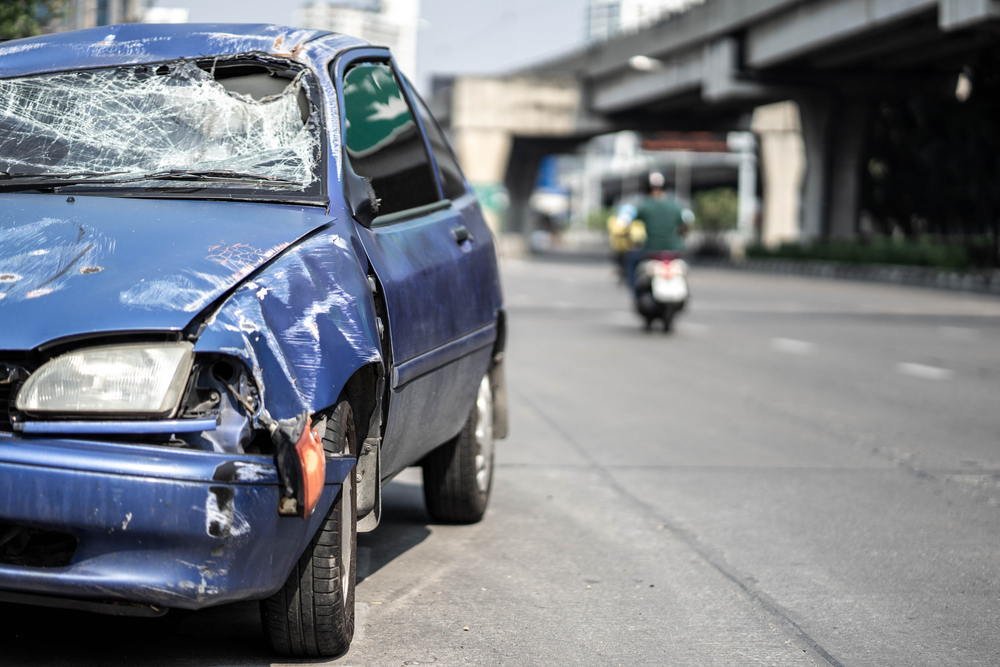

In [16]:
sample_image = images_df.query("image_exists").sample(1, random_state=42).iloc[0]
sample_annotations = annotations_df[
    (annotations_df["split"] == sample_image["split"]) &
    (annotations_df["image_id"] == sample_image["id"])
]

print(sample_image[["split", "id", "file_name", "width", "height", "image_path"]])
display(sample_annotations[["id", "category_id", "category_name", "area", "bbox"]].head())

Image.open(sample_image["image_path"])

## Class distribution

split,test,train,val,total
category_name,,,,
scratch,307,2560,728,3595
dent,236,1806,501,2543
crack,70,651,177,898
lamp broken,69,494,141,704
glass shatter,71,475,135,681
tire flat,32,225,62,319


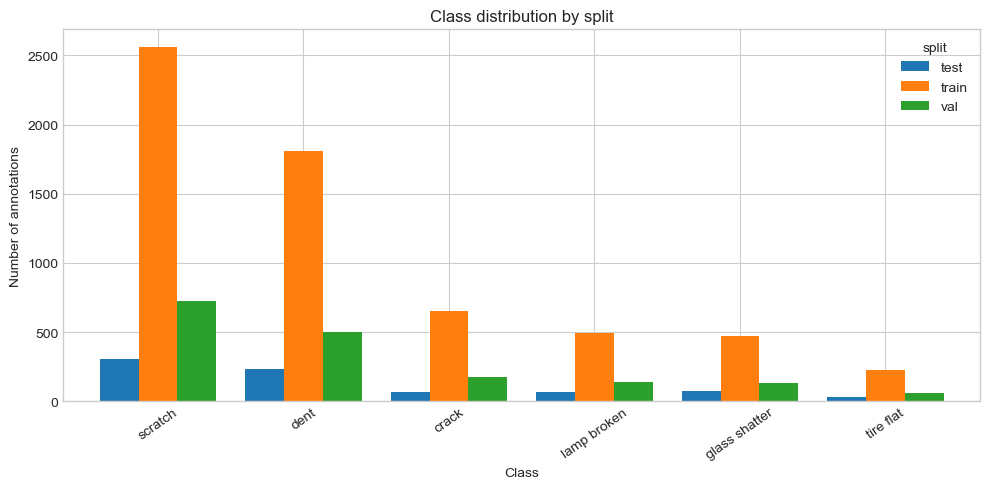

In [17]:
class_distribution = (
    annotations_df
    .groupby(["split", "category_name"])
    .size()
    .rename("annotations")
    .reset_index()
)

class_pivot = (
    class_distribution
    .pivot(index="category_name", columns="split", values="annotations")
    .fillna(0)
    .astype(int)
)
class_pivot["total"] = class_pivot.sum(axis=1)
class_pivot = class_pivot.sort_values("total", ascending=False)

display(class_pivot)

ax = class_pivot.drop(columns="total").plot(kind="bar", figsize=(10, 5), width=0.8)
ax.set_title("Class distribution by split")
ax.set_xlabel("Class")
ax.set_ylabel("Number of annotations")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## Bbox size distribution

,bbox_width,bbox_height,bbox_area,bbox_area_ratio,bbox_aspect_ratio
count,8740.000000,8740.000000,8740.000000,8740.000000,8740.000000
mean,343.031375,251.967538,117396.778473,0.171965,1.719900
std,251.604636,178.640909,150838.883730,0.220753,1.551802
min,7.510000,7.350000,116.616600,0.000175,0.048396
1%,19.806300,19.909200,711.957038,0.001031,0.235955
5%,49.728000,40.419000,2827.939765,0.004121,0.420727
25%,145.160000,108.830000,16818.641700,0.024646,0.866024
50%,277.750000,205.425000,54233.657600,0.079700,1.332353
75%,482.952500,357.762500,155707.979175,0.224889,2.035670
95%,890.597500,615.341500,468186.762670,0.691251,4.281597


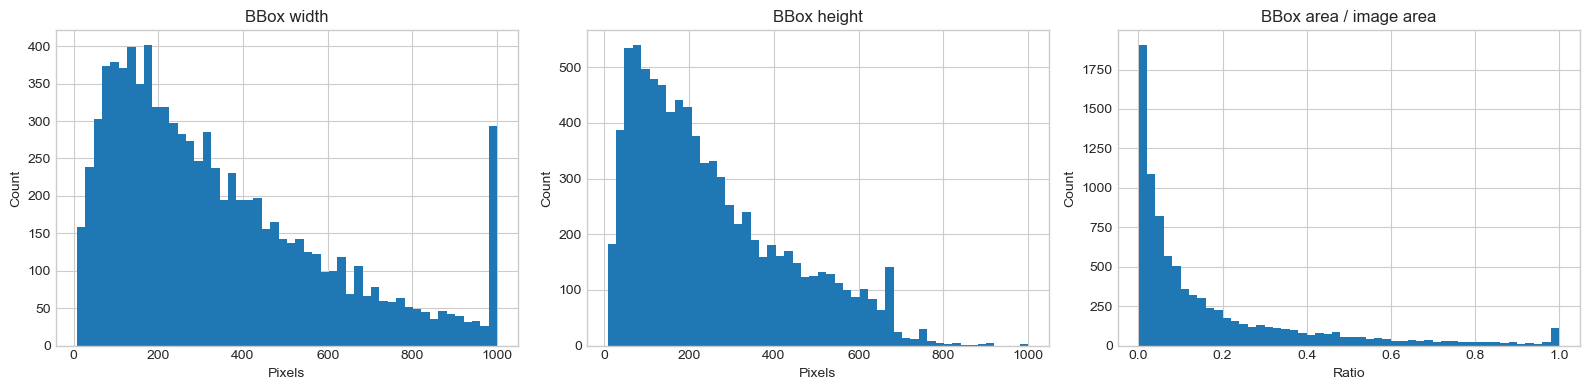

In [18]:
annotations_with_images_df = annotations_df.merge(
    images_df[["split", "id", "width", "height", "file_name", "image_path"]],
    left_on=["split", "image_id"],
    right_on=["split", "id"],
    how="left",
    suffixes=("", "_image"),
)

annotations_with_images_df["bbox_area"] = annotations_with_images_df["bbox_width"] * annotations_with_images_df["bbox_height"]
annotations_with_images_df["bbox_area_ratio"] = annotations_with_images_df["bbox_area"] / (
    annotations_with_images_df["width"] * annotations_with_images_df["height"]
)
annotations_with_images_df["bbox_aspect_ratio"] = annotations_with_images_df["bbox_width"] / annotations_with_images_df["bbox_height"]

display(
    annotations_with_images_df[
        ["bbox_width", "bbox_height", "bbox_area", "bbox_area_ratio", "bbox_aspect_ratio"]
    ].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(annotations_with_images_df["bbox_width"], bins=50)
axes[0].set_title("BBox width")
axes[0].set_xlabel("Pixels")

axes[1].hist(annotations_with_images_df["bbox_height"], bins=50)
axes[1].set_title("BBox height")
axes[1].set_xlabel("Pixels")

axes[2].hist(annotations_with_images_df["bbox_area_ratio"], bins=50)
axes[2].set_title("BBox area / image area")
axes[2].set_xlabel("Ratio")

for ax in axes:
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Image resolutions

,width,height,image_area
count,4000.000000,4000.000000,4000.000000
mean,978.058500,706.172750,684231.250000
std,79.594095,97.850087,54887.283836
min,562.000000,333.000000,333000.000000
25%,1000.000000,667.000000,667000.000000
50%,1000.000000,667.000000,667000.000000
75%,1000.000000,750.000000,674000.000000
max,1000.000000,1000.000000,1000000.000000


,resolution,images
0,1000x667,1969
1,1000x750,582
2,1000x668,210
3,667x1000,108
4,1000x664,100
5,1000x662,93
6,750x1000,84
7,1000x665,78
8,1000x563,69
9,1000x666,58


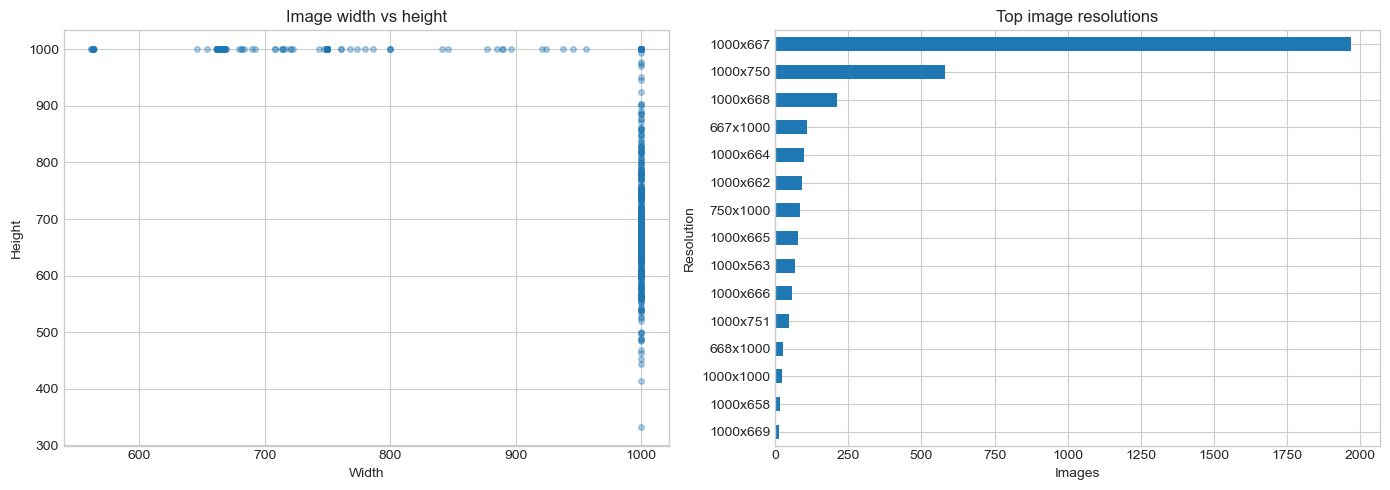

In [19]:
images_df["resolution"] = images_df["width"].astype(str) + "x" + images_df["height"].astype(str)
images_df["image_area"] = images_df["width"] * images_df["height"]

display(images_df[["width", "height", "image_area"]].describe())
display(images_df["resolution"].value_counts().head(20).rename_axis("resolution").reset_index(name="images"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(images_df["width"], images_df["height"], alpha=0.35, s=16)
axes[0].set_title("Image width vs height")
axes[0].set_xlabel("Width")
axes[0].set_ylabel("Height")

images_df["resolution"].value_counts().head(15).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Top image resolutions")
axes[1].set_xlabel("Images")
axes[1].set_ylabel("Resolution")

plt.tight_layout()
plt.show()

## Aspect ratios

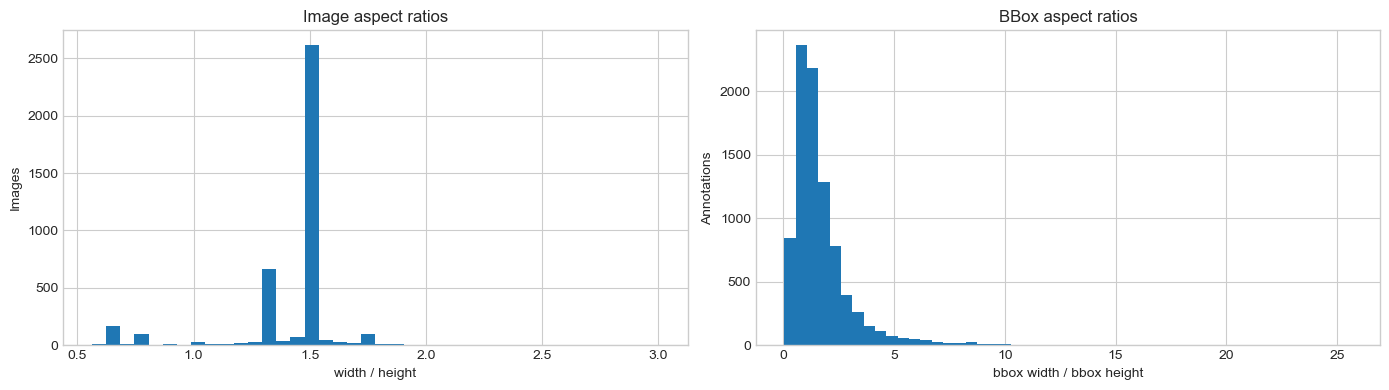

,image_aspect_ratio
count,4000.000000
mean,1.416383
std,0.229340
min,0.562000
25%,1.333333
50%,1.499250
75%,1.499250
max,3.003003


,bbox_aspect_ratio
count,8740.000000
mean,1.719900
std,1.551802
min,0.048396
25%,0.866024
50%,1.332353
75%,2.035670
max,25.659193


In [20]:
images_df["image_aspect_ratio"] = images_df["width"] / images_df["height"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(images_df["image_aspect_ratio"], bins=40)
axes[0].set_title("Image aspect ratios")
axes[0].set_xlabel("width / height")
axes[0].set_ylabel("Images")

axes[1].hist(annotations_with_images_df["bbox_aspect_ratio"].replace([np.inf, -np.inf], np.nan).dropna(), bins=50)
axes[1].set_title("BBox aspect ratios")
axes[1].set_xlabel("bbox width / bbox height")
axes[1].set_ylabel("Annotations")

plt.tight_layout()
plt.show()

display(images_df[["image_aspect_ratio"]].describe())
display(annotations_with_images_df[["bbox_aspect_ratio"]].describe())

## Bbox heatmap

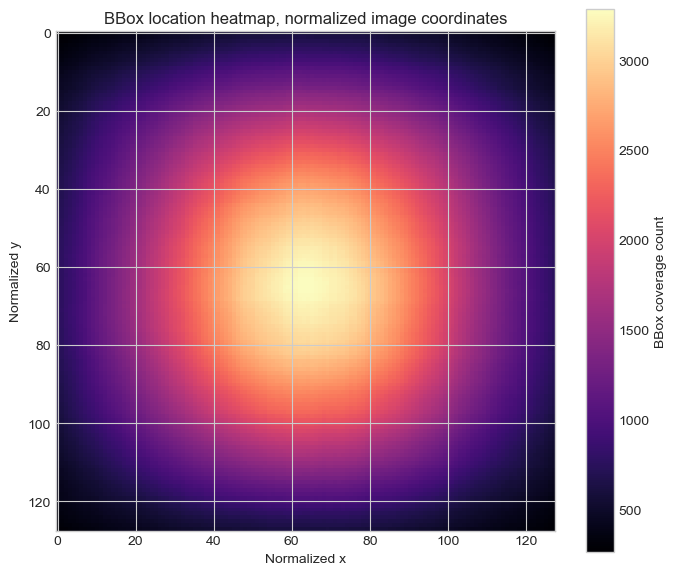

In [21]:
heatmap_size = 128
bbox_heatmap = np.zeros((heatmap_size, heatmap_size), dtype=np.float32)

for row in annotations_with_images_df.dropna(subset=["width", "height"]).itertuples(index=False):
    x1 = int(np.clip(row.bbox_x / row.width * heatmap_size, 0, heatmap_size - 1))
    y1 = int(np.clip(row.bbox_y / row.height * heatmap_size, 0, heatmap_size - 1))
    x2 = int(np.clip((row.bbox_x + row.bbox_width) / row.width * heatmap_size, 0, heatmap_size))
    y2 = int(np.clip((row.bbox_y + row.bbox_height) / row.height * heatmap_size, 0, heatmap_size))

    if x2 > x1 and y2 > y1:
        bbox_heatmap[y1:y2, x1:x2] += 1

plt.figure(figsize=(7, 6))
plt.imshow(bbox_heatmap, cmap="magma")
plt.title("BBox location heatmap, normalized image coordinates")
plt.xlabel("Normalized x")
plt.ylabel("Normalized y")
plt.colorbar(label="BBox coverage count")
plt.tight_layout()
plt.show()

## Examples

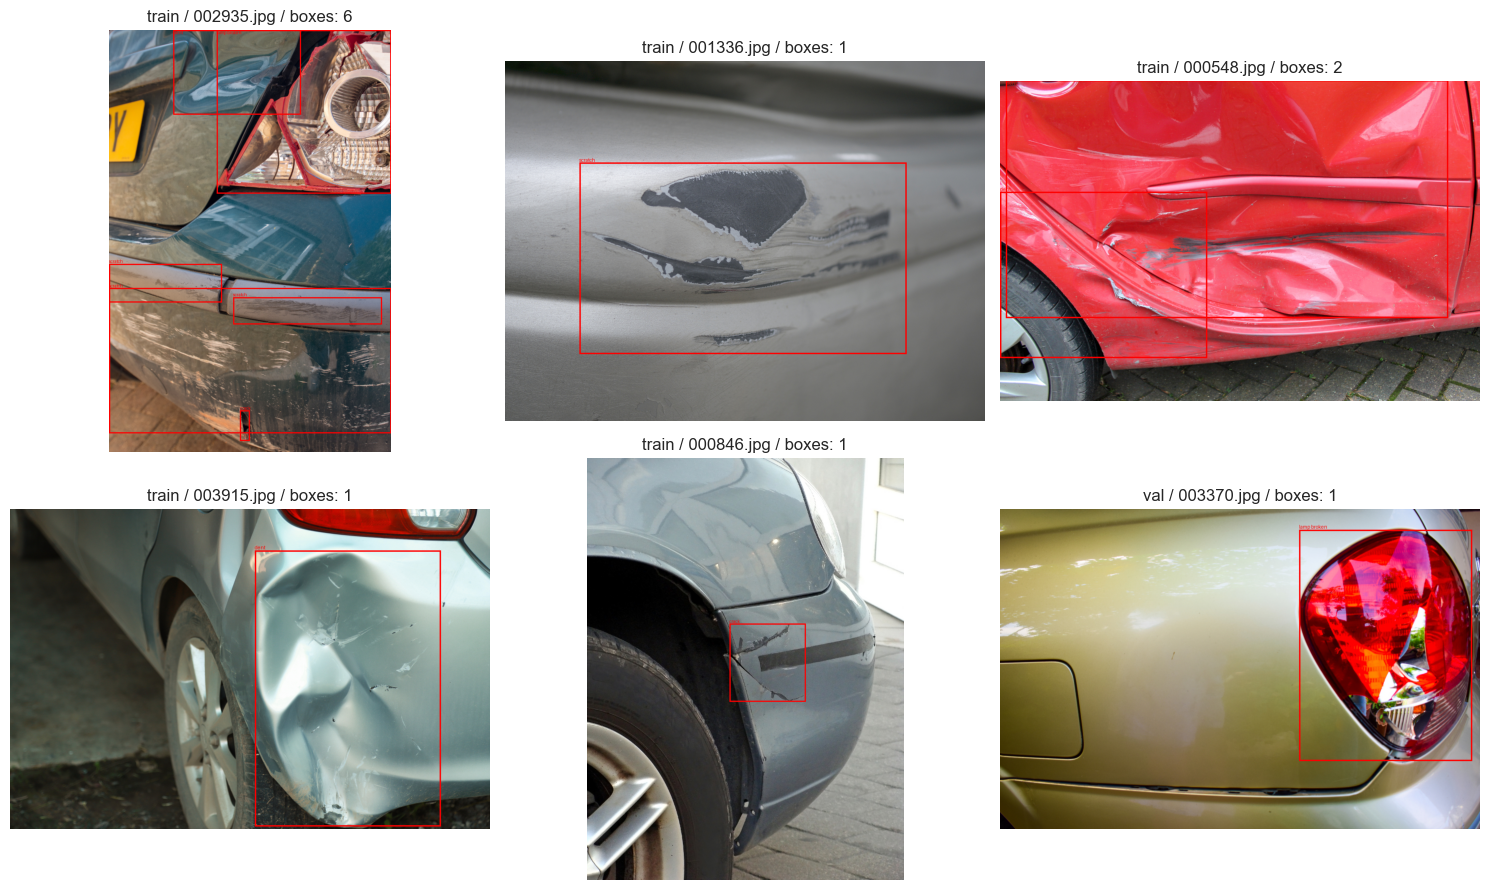

In [22]:
def draw_bboxes(image_row: pd.Series, annotations: pd.DataFrame) -> Image.Image:
    image = Image.open(image_row["image_path"]).convert("RGB")
    draw = ImageDraw.Draw(image)

    for ann in annotations.itertuples(index=False):
        x, y, w, h = ann.bbox
        label = ann.category_name
        color = "red"
        draw.rectangle([x, y, x + w, y + h], outline=color, width=3)
        draw.text((x, max(0, y - 12)), label, fill=color)

    return image


example_images = images_df.query("image_exists").sample(6, random_state=7)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (_, image_row) in zip(axes.ravel(), example_images.iterrows()):
    image_annotations = annotations_df[
        (annotations_df["split"] == image_row["split"]) &
        (annotations_df["image_id"] == image_row["id"])
    ]
    ax.imshow(draw_bboxes(image_row, image_annotations))
    ax.set_title(f"{image_row['split']} / {image_row['file_name']} / boxes: {len(image_annotations)}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Rare classes

split,test,train,val,total
category_name,,,,
glass shatter,71,475,135,681
tire flat,32,225,62,319


,split,file_name,category_name,bbox,bbox_area_ratio,image_path
7974,test,000042.jpg,glass shatter,"[232.02, 120.5, 439.0, 131.03]",0.086240,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/test2017/000042.jpg
7984,test,000090.jpg,glass shatter,"[58.85, 206.35, 770.6, 415.09]",0.435195,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/test2017/000090.jpg
7993,test,000165.jpg,glass shatter,"[33.42, 43.8, 966.58, 609.29]",0.851051,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/test2017/000165.jpg
7994,test,000175.jpg,glass shatter,"[216.14, 2.5, 783.86, 664.5]",0.780922,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/test2017/000175.jpg
7995,test,000185.jpg,glass shatter,"[135.48, 122.58, 665.17, 539.36]",0.537880,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/test2017/000185.jpg
8001,test,000204.jpg,glass shatter,"[194.4, 81.41, 618.85, 387.69]",0.359703,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/test2017/000204.jpg
8002,test,000214.jpg,glass shatter,"[0.0, 0.0, 1000.0, 667.0]",1.000000,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/test2017/000214.jpg
8004,test,000224.jpg,glass shatter,"[0.0, 154.97, 1000.0, 333.67]",0.500255,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/test2017/000224.jpg
8005,test,000233.jpg,glass shatter,"[327.37, 122.14, 672.63, 396.55]",0.377272,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/test2017/000233.jpg
8010,test,000253.jpg,glass shatter,"[17.07, 48.45, 982.93, 478.33]",0.704895,/Users/ektar/Desktop/Python Projects/car-damage-e2e/data/raw/CarDD_COCO/test2017/000253.jpg


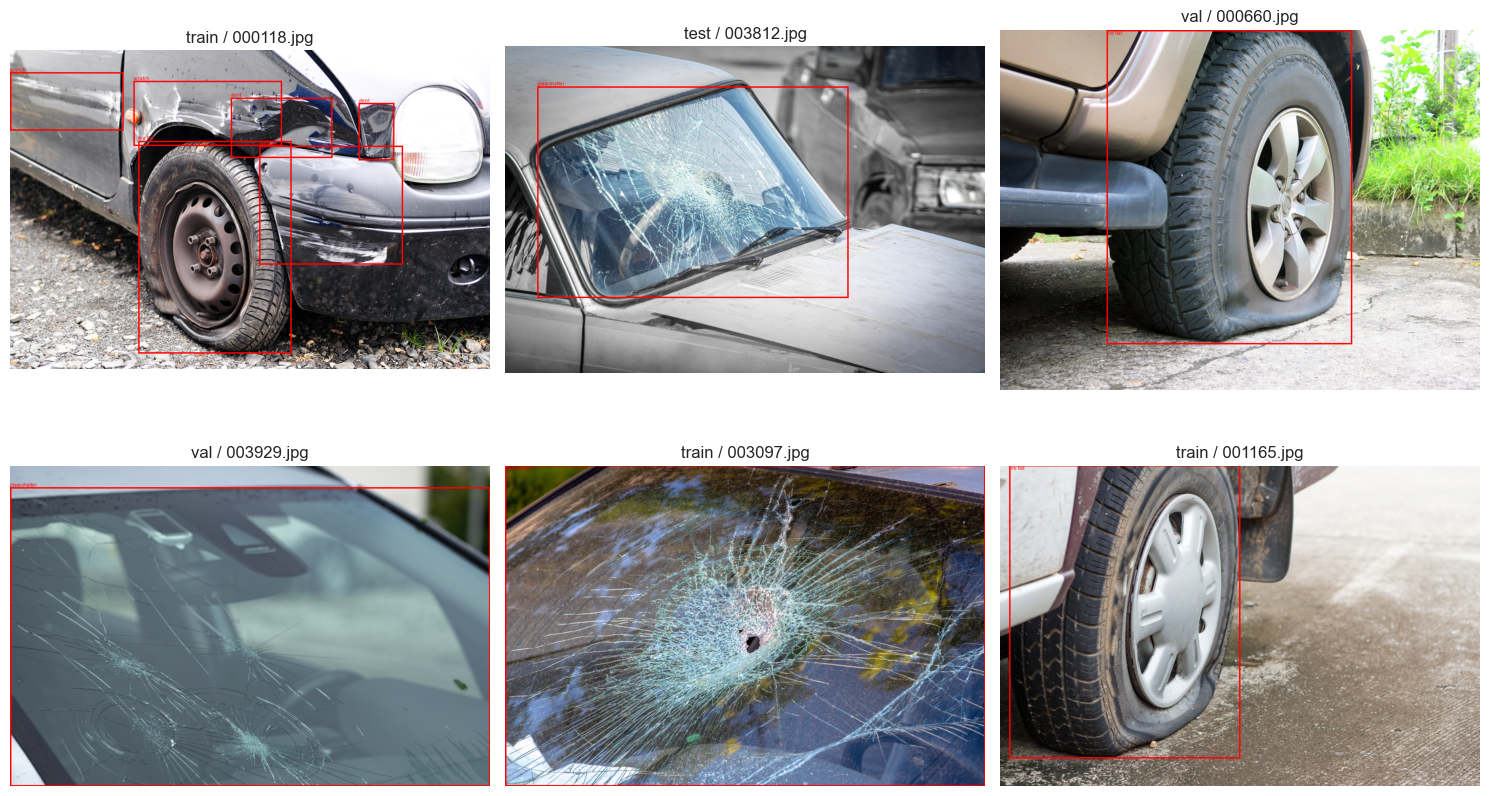

In [23]:
rare_threshold = class_pivot["total"].quantile(0.25)
rare_classes = class_pivot[class_pivot["total"] <= rare_threshold].copy()

display(rare_classes)

rare_examples = annotations_with_images_df[
    annotations_with_images_df["category_name"].isin(rare_classes.index)
].copy()

display(
    rare_examples[
        ["split", "file_name", "category_name", "bbox", "bbox_area_ratio", "image_path"]
    ].sort_values(["category_name", "split"]).head(20)
)

if not rare_examples.empty:
    rare_image_rows = (
        rare_examples[["split", "image_id"]]
        .drop_duplicates()
        .sample(min(6, rare_examples[["split", "image_id"]].drop_duplicates().shape[0]), random_state=11)
    )
    rare_images = rare_image_rows.merge(
        images_df,
        left_on=["split", "image_id"],
        right_on=["split", "id"],
        how="left",
    )

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes_flat = axes.ravel()
    for ax in axes_flat:
        ax.axis("off")

    for ax, (_, image_row) in zip(axes_flat, rare_images.iterrows()):
        image_annotations = annotations_df[
            (annotations_df["split"] == image_row["split"]) &
            (annotations_df["image_id"] == image_row["id"])
        ]
        ax.imshow(draw_bboxes(image_row, image_annotations))
        ax.set_title(f"{image_row['split']} / {image_row['file_name']}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()